In [10]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
df = pd.read_csv("../data/XOM_SP500_2024_2026.csv", index_col=0, parse_dates=True)
df.head()

,XOM,SP500,XOM_Return,SP500_Return
Date,,,,
2024-01-03,94.388016,4704.810059,0.008367,-0.008049
2024-01-04,93.565025,4688.680176,-0.008757,-0.003434
2024-01-05,93.848495,4697.240234,0.003025,0.001824
2024-01-08,92.284821,4763.540039,-0.016802,0.014016
2024-01-09,91.141769,4756.500000,-0.012463,-0.001479


In [12]:
# Biến phụ thuộc Y: Tỷ suất sinh lợi của XOM
Y = df['XOM_Return']

# Biến độc lập X: Tỷ suất sinh lợi của thị trường (S&P 500)
X = df['SP500_Return']

# Thêm hằng số (constant) vào mô hình để tính Alpha
X = sm.add_constant(X)

print("Biến X và Y đã được khai báo sẵn sàng cho mô hình OLS.")

Biến X và Y đã được khai báo sẵn sàng cho mô hình OLS.


In [13]:
# Chạy mô hình hồi quy
model = sm.OLS(Y, X).fit()

# In bảng tóm tắt kết quả (Summary)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             XOM_Return   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     8.861
Date:                Tue, 29 Sep 2026   Prob (F-statistic):            0.00302
Time:                        17:32:18   Log-Likelihood:                 1920.1
No. Observations:                 686   AIC:                            -3836.
Df Residuals:                     684   BIC:                            -3827.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0007      0.001      1.206   

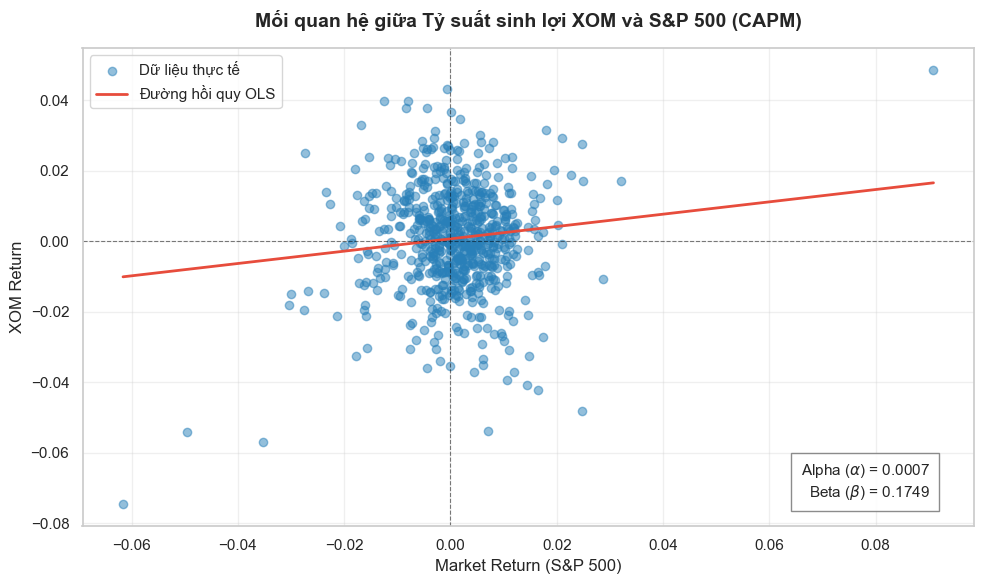

In [14]:
plt.figure(figsize=(10, 6))

# 1. Vẽ Scatter Plot
plt.scatter(df['SP500_Return'], df['XOM_Return'], alpha=0.5, color='#2980B9', label='Dữ liệu thực tế')

# 2. Tính toán và vẽ đường hồi quy (Line Plot)
x_pred = np.linspace(df['SP500_Return'].min(), df['SP500_Return'].max(), 100)
x_pred_const = sm.add_constant(x_pred)
y_pred = model.predict(x_pred_const)
plt.plot(x_pred, y_pred, color='#E74C3C', linewidth=2, label='Đường hồi quy OLS')

# 3. Trích xuất Alpha, Beta
alpha_val = model.params['const']
beta_val = model.params['SP500_Return']
text_box = f'Alpha ($\\alpha$) = {alpha_val:.4f}\nBeta ($\\beta$) = {beta_val:.4f}'

plt.text(0.95, 0.05, text_box,
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='square,pad=0.6', facecolor='white', edgecolor='gray', alpha=0.9))

# 4. Định dạng tiêu đề và các trục
plt.title('Mối quan hệ giữa Tỷ suất sinh lợi XOM và S&P 500 (CAPM)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Market Return (S&P 500)', fontsize=12)
plt.ylabel('XOM Return', fontsize=12)

# 5. Kẻ vạch tọa độ 0 và lưới nền
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.grid(True, alpha=0.3)

plt.legend(loc='upper left')

plt.tight_layout()
plt.show()